# License Plate Detection and Recognition Pipeline

This project builds a two-stage license plate recognition pipeline.

**Pipeline:** vehicle image → YOLOv8 detector → plate crop → EasyOCR → cleaned plate text

The detector is evaluated with IoU against ground-truth boxes. OCR is evaluated with exact-match accuracy and character error rate (CER).


## 1. Setup


In [1]:
!pip install -q ultralytics easyocr


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 972.1/972.1 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 20.7 MB/s eta 0:00:00


In [2]:
import os
import re
import cv2
import yaml
import torch
import easyocr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from ultralytics import YOLO

print("GPU available:", torch.cuda.is_available())


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
GPU available: True


## 2. Dataset

I use the Roboflow **License Plates v3** object-detection dataset. It contains 350 images split into 245 train, 70 validation, and 35 test images. The two classes are `license-plate` and `vehicle`.

The download token is kept outside the notebook so it is not exposed in a public GitHub repository.


In [3]:
DATASET_URL = "https://public.roboflow.com/ds/T891kVPkiJ?key=YmJuoYQISX"

if DATASET_URL:
    !wget -q "$DATASET_URL" -O license_plates.zip
    !rm -rf license_plates
    !unzip -q license_plates.zip -d license_plates
else:
    print("Set DATASET_URL before running this cell.")


In [4]:
yaml_path = "/content/license_plates/data.yaml"

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

data["train"] = "/content/license_plates/train/images"
data["val"] = "/content/license_plates/valid/images"
data["test"] = "/content/license_plates/test/images"

with open(yaml_path, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print(data)

train_images = sorted(Path(data["train"]).glob("*"))
val_images = sorted(Path(data["val"]).glob("*"))
test_images = sorted(Path(data["test"]).glob("*"))

print("Train:", len(train_images))
print("Validation:", len(val_images))
print("Test:", len(test_images))


{'train': '/content/license_plates/train/images', 'val': '/content/license_plates/valid/images', 'test': '/content/license_plates/test/images', 'nc': 2, 'names': ['license-plate', 'vehicle'], 'roboflow': {'workspace': 'samrat-sahoo', 'project': 'license-plates-f8vsn', 'version': 3, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/samrat-sahoo/license-plates-f8vsn/dataset/3'}}
Train: 245
Validation: 70
Test: 35


## 3. Train YOLOv8

I fine-tune YOLOv8 Nano on the training split for 30 epochs. The validation split is used during training, while the test split stays held out for final evaluation.


In [5]:
model = YOLO("yolov8n.pt")

model.train(
    data=yaml_path,
    epochs=30,
    imgsz=640,
    batch=16,
    name="license_plate_detector",
    seed=42
)


Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/license_plates/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=license_plate_detector, nbs=64, nms=None, o

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x792efe3c3230>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

### Validation result

My training run produced the following results for the `license-plate` class:

- Precision: **93.7%**
- Recall: **88.1%**
- mAP@50: **92.2%**
- mAP@50-95: **68.7%**


In [6]:
best_model = YOLO("/content/runs/detect/license_plate_detector/weights/best.pt")


## 4. IoU evaluation


In [7]:
def yolo_to_xyxy(line, img_w, img_h):
    cls, xc, yc, w, h = map(float, line.split())
    xc, w = xc * img_w, w * img_w
    yc, h = yc * img_h, h * img_h
    return int(cls), [xc-w/2, yc-h/2, xc+w/2, yc+h/2]

def calculate_iou(a, b):
    x1, y1 = max(a[0], b[0]), max(a[1], b[1])
    x2, y2 = min(a[2], b[2]), min(a[3], b[3])

    intersection = max(0, x2-x1) * max(0, y2-y1)
    area_a = max(0, a[2]-a[0]) * max(0, a[3]-a[1])
    area_b = max(0, b[2]-b[0]) * max(0, b[3]-b[1])
    union = area_a + area_b - intersection

    return intersection / union if union else 0

def get_gt_boxes(image_path):
    image = cv2.imread(str(image_path))
    h, w = image.shape[:2]
    label_path = Path("/content/license_plates/test/labels") / f"{image_path.stem}.txt"

    boxes = []
    if label_path.exists():
        for line in label_path.read_text().splitlines():
            cls, box = yolo_to_xyxy(line, w, h)
            if cls == 0:
                boxes.append(box)
    return boxes

def get_pred_boxes(image_path, conf=0.25):
    result = best_model.predict(str(image_path), conf=conf, verbose=False)[0]
    boxes = []

    for b in result.boxes:
        if int(b.cls[0].item()) == 0:
            boxes.append({
                "box": b.xyxy[0].cpu().numpy().tolist(),
                "confidence": float(b.conf[0].item())
            })
    return boxes


In [8]:
iou_rows = []

for image_path in test_images:
    gt_boxes = get_gt_boxes(image_path)
    predictions = get_pred_boxes(image_path)
    used = set()

    for gt_box in gt_boxes:
        best_score, best_id, best_box = 0, None, None

        for j, pred in enumerate(predictions):
            if j in used:
                continue

            score = calculate_iou(gt_box, pred["box"])
            if score > best_score:
                best_score = score
                best_id = j
                best_box = pred["box"]

        if best_id is not None:
            used.add(best_id)

        iou_rows.append({
            "image": image_path.name,
            "ground_truth_box": [round(x, 1) for x in gt_box],
            "predicted_box": None if best_box is None else [round(x, 1) for x in best_box],
            "IoU": round(best_score, 4)
        })

iou_df = pd.DataFrame(iou_rows)

display(iou_df)
print("Test images:", len(test_images))
print("Ground-truth plates:", len(iou_df))
print("Mean IoU:", round(iou_df["IoU"].mean(), 4))


,image,ground_truth_box,predicted_box,IoU
0,b15d6c0bdf90226d_jpg.rf.775557ba6aaf7d76a8d4bb...,"[355.5, 278.8, 383.5, 318.2]","[354.3, 279.4, 381.9, 318.7]",0.8810
1,b193070a9c45b5ab_jpg.rf.57e5987eb896a7bf9fc7a1...,"[81.5, 240.5, 126.5, 268.5]","[81.0, 240.3, 126.7, 268.4]",0.9745
2,b1a50a3824887ee2_jpg.rf.68a4fd34fce20184287592...,"[155.5, 319.0, 232.5, 366.0]","[154.6, 319.8, 233.8, 368.1]",0.9152
3,b1a50a3824887ee2_jpg.rf.68a4fd34fce20184287592...,"[220.5, 94.5, 223.5, 99.5]",None,0.0000
4,b25d7d2cb7abf86b_jpg.rf.36edce738b0e69965e0010...,"[170.0, 258.2, 248.0, 316.8]","[169.3, 257.3, 248.4, 316.7]",0.9698
5,b25d7d2cb7abf86b_jpg.rf.36edce738b0e69965e0010...,"[407.2, 107.2, 415.8, 128.8]",None,0.0000
6,b32671b7cc279583_jpg.rf.f898026e2169a3b6adc4d2...,"[60.8, 171.2, 167.2, 230.8]",None,0.0000
7,b3b61da98e22cd4a_jpg.rf.e5f31065702d60c5746652...,"[298.2, 186.2, 340.8, 233.8]","[298.4, 186.4, 341.4, 236.8]",0.9208
8,b5e7183b6a5abe6c_jpg.rf.fa89af80aebfc925bb0121...,"[224.2, 292.8, 281.8, 333.2]","[224.3, 294.8, 280.4, 331.6]",0.8849
9,b6580dec5ada277d_jpg.rf.3ec17c0d68df1e6818d590...,"[92.0, 184.3, 176.0, 258.8]","[94.1, 186.7, 173.9, 259.5]",0.9108


Test images: 35
Ground-truth plates: 45
Mean IoU: 0.7478


## 5. Plate cropping

All OCR crops come from model detections. No manual crop coordinates are used in the pipeline.


In [9]:
def crop_plate(image, box, padding=0.08):
    h, w = image.shape[:2]
    x1, y1, x2, y2 = box

    px = (x2-x1) * padding
    py = (y2-y1) * padding

    x1 = max(0, int(x1-px))
    y1 = max(0, int(y1-py))
    x2 = min(w, int(x2+px))
    y2 = min(h, int(y2+py))

    return image[y1:y2, x1:x2]


### Multiple-vehicle examples

I find images with at least two vehicles and test plate extraction on three of them.


Multiple-vehicle images: 19


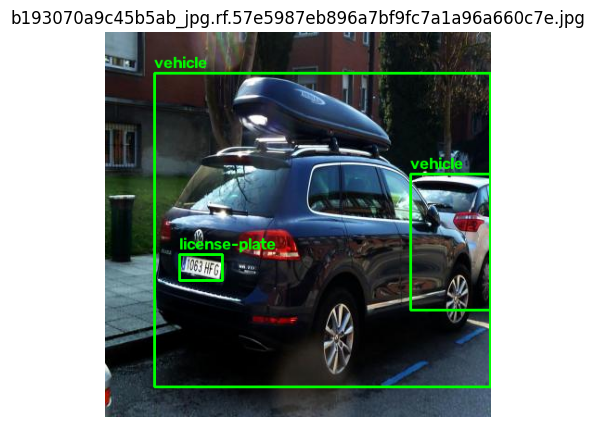

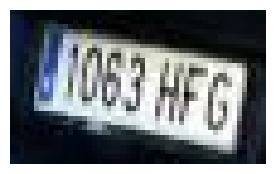

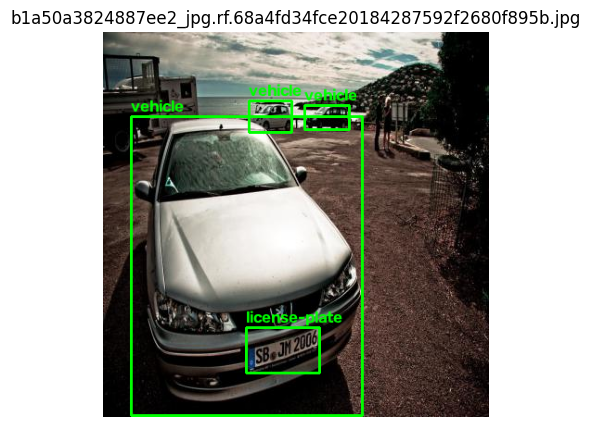

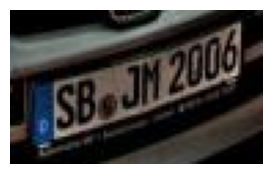

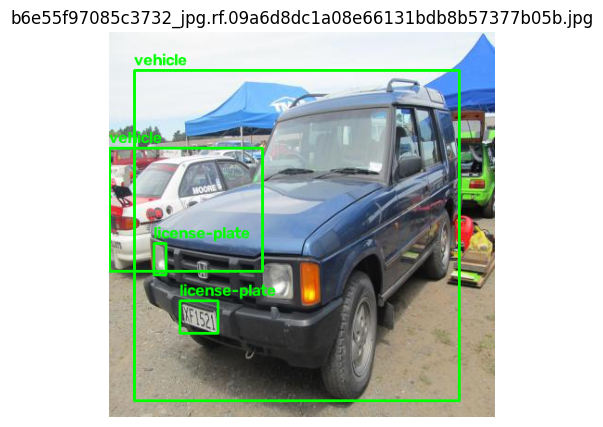

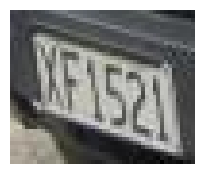

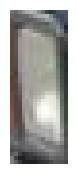

In [10]:
multi_vehicle = []

for image_path in test_images:
    result = best_model.predict(str(image_path), conf=0.25, verbose=False)[0]
    vehicle_count = sum(int(b.cls[0].item()) == 1 for b in result.boxes)

    if vehicle_count >= 2:
        multi_vehicle.append(image_path)

print("Multiple-vehicle images:", len(multi_vehicle))

for image_path in multi_vehicle[:3]:
    image = cv2.imread(str(image_path))
    result = best_model.predict(str(image_path), conf=0.25, verbose=False)[0]
    shown = image.copy()
    crops = []

    for b in result.boxes:
        cls = int(b.cls[0].item())
        box = b.xyxy[0].cpu().numpy().tolist()
        x1, y1, x2, y2 = map(int, box)

        cv2.rectangle(shown, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(shown, best_model.names[cls], (x1, max(20,y1-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, .6, (0,255,0), 2)

        if cls == 0:
            crops.append(crop_plate(image, box))

    plt.figure(figsize=(9,5))
    plt.imshow(cv2.cvtColor(shown, cv2.COLOR_BGR2RGB))
    plt.title(image_path.name)
    plt.axis("off")
    plt.show()

    for crop in crops:
        plt.figure(figsize=(5,2))
        plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()


## 6. EasyOCR


In [11]:
reader = easyocr.Reader(["en"], gpu=torch.cuda.is_available())

def read_plate(crop):
    if crop is None or crop.size == 0:
        return ""

    rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    result = reader.readtext(rgb, detail=0, paragraph=False)
    return " ".join(result)


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

## 7. Text cleaning

The basic cleaner removes spaces and punctuation and converts the result to uppercase.

The second function demonstrates rule-based `0/O` and `1/I` correction when a known plate pattern is available. I do not force this format on every image because the dataset contains plates from different countries.


In [12]:
def clean_text(text):
    return re.sub(r"[^A-Z0-9]", "", text.upper())

def clean_with_format(text, pattern):
    text = clean_text(text)

    if len(text) != len(pattern):
        return text

    chars = list(text)

    for i, expected in enumerate(pattern):
        if expected == "L":
            chars[i] = {"0":"O", "1":"I"}.get(chars[i], chars[i])
        elif expected == "D":
            chars[i] = {"O":"0", "I":"1"}.get(chars[i], chars[i])

    return "".join(chars)


## 8. OCR ground truth

For OCR evaluation, I transcribed the visible plate strings from held-out test images. Ground-truth boxes are used only for reference during transcription; the end-to-end pipeline still crops plates from YOLO predictions.


In [13]:
ocr_ground_truth = {'b1a50a3824887ee2_jpg.rf.68a4fd34fce20184287592f2680f895b.jpg': ['SBJM2004'], 'b25d7d2cb7abf86b_jpg.rf.36edce738b0e69965e001035d6f85ab3.jpg': ['UW3932'], 'b32671b7cc279583_jpg.rf.f898026e2169a3b6adc4d21aee6d06c5.jpg': ['208'], 'b5e7183b6a5abe6c_jpg.rf.fa89af80aebfc925bb0121ab5b024260.jpg': ['BBX3499'], 'b6580dec5ada277d_jpg.rf.3ec17c0d68df1e6818d590e410bc3d00.jpg': ['1005601'], 'b6ecda23586a6ba5_jpg.rf.d737139968dd3f08447305aa7b7f6002.jpg': ['EEM927'], 'b7cdb5c0c99002b7_jpg.rf.2c46810fbf4036039cb03a135e20e9c3.jpg': ['HV13DTP'], 'b94993a2d67b455e_jpg.rf.62712d980344cb842644f82e63b13092.jpg': ['WWY4259'], 'b9f5b9acf1777acf_jpg.rf.b92969d5c3738ece6a84dcd2d0ea3ce0.jpg': ['GLENIE'], 'bbcac63e32bd8137_jpg.rf.ef4704b0ada4fbbf613143abf52f6f86.jpg': ['FAG643'], 'be9fd0014b5a4f2a_jpg.rf.20dc7369d0a83ad74a123727228dce11.jpg': ['2122267'], 'bf0aac0878b0a3d2_jpg.rf.43ce523ba85e649db07055557d72cc9e.jpg': ['ILUVHIZE'], 'bf2f25f3ed9ff4d5_jpg.rf.e9d07ec8b85372d40366bc2770b7d537.jpg': ['V147JAR'], 'c274e026ac907eb9_jpg.rf.2388de7229ba0dd3051326f64c1a770b.jpg': ['6'], 'c650ff8d3e8e75b3_jpg.rf.a469a8f0edb8fddf8e2b70b102f5a5eb.jpg': ['TL296'], 'c7df5232291486a3_jpg.rf.d18b52a383576cfe6c4ec343fca07a80.jpg': ['MM64UMA'], 'c91ee912164d8ecb_jpg.rf.5a70d8b40bde25a3a4cb09337bf0c6f9.jpg': ['WU341A'], 'cb8c75fc1c7ccf73_jpg.rf.a6d315cf4a3ef0824075df8c8561838b.jpg': ['PCJ5661'], 'ccc1a2d44a290368_jpg.rf.8e8d6f87f1d1327caf5f80e0c96cdad9.jpg': ['C26727'], 'cdb1e8621d1c624e_jpg.rf.b744b93a7af0771f1e5cb955155c8451.jpg': ['PIGO321'], 'd27e094e98374ff8_jpg.rf.a0e0eba539117b97eb6433295c4cfb44.jpg': ['M5CEU'], 'd2fe2b47668e9d8e_jpg.rf.c3c019d146ec1fc0bcf7fbeb12c7bc7f.jpg': ['1CNC1']}


## 9. Character error rate


In [15]:
def edit_distance(a, b):
    dp = np.zeros((len(a)+1, len(b)+1), dtype=int)
    dp[:, 0] = np.arange(len(a)+1)
    dp[0, :] = np.arange(len(b)+1)

    for i in range(1, len(a)+1):
        for j in range(1, len(b)+1):
            cost = 0 if a[i-1] == b[j-1] else 1
            dp[i,j] = min(
                dp[i-1,j] + 1,
                dp[i,j-1] + 1,
                dp[i-1,j-1] + cost
            )
    return dp[-1,-1]

def cer(truth, prediction):
    truth = clean_text(truth)
    prediction = clean_text(prediction)

    if not truth:
        return 0 if not prediction else 1

    return edit_distance(truth, prediction) / len(truth)


## 10. End-to-end pipeline

This function handles zero, one, or multiple detected plates and returns the box, confidence, raw OCR result, and cleaned text.


In [16]:
def recognize_plates(image_path, conf=0.25, padding=0.08, pattern=None):
    image = cv2.imread(str(image_path))

    if image is None:
        raise ValueError(f"Could not read: {image_path}")

    result = best_model.predict(str(image_path), conf=conf, verbose=False)[0]
    output = []

    for b in result.boxes:
        if int(b.cls[0].item()) != 0:
            continue

        box = b.xyxy[0].cpu().numpy().tolist()
        crop = crop_plate(image, box, padding)
        raw_text = read_plate(crop)

        output.append({
            "box": [round(x,1) for x in box],
            "confidence": round(float(b.conf[0].item()), 4),
            "raw_text": raw_text,
            "cleaned_text": clean_with_format(raw_text, pattern) if pattern else clean_text(raw_text),
            "crop": crop
        })

    return output


In [17]:
sample = test_images[0]
print("Image:", sample.name)

for plate in recognize_plates(sample):
    print({k:v for k,v in plate.items() if k != "crop"})


Image: b15d6c0bdf90226d_jpg.rf.775557ba6aaf7d76a8d4bb04f66d8fc5.jpg
{'box': [354.3, 279.4, 381.9, 318.7], 'confidence': 0.8217, 'raw_text': '', 'cleaned_text': ''}


## 11. End-to-end accuracy report


In [18]:
def left_to_right(items):
    return sorted(items, key=lambda x: x[0])

report_rows = []

for image_path in test_images:
    if image_path.name not in ocr_ground_truth:
        continue

    gt_texts = ocr_ground_truth[image_path.name]
    gt_boxes = left_to_right(get_gt_boxes(image_path))[:len(gt_texts)]
    outputs = recognize_plates(image_path)
    used = set()

    for i, gt_box in enumerate(gt_boxes):
        truth = clean_text(gt_texts[i]) if i < len(gt_texts) else ""
        best_score, best_id = 0, None

        for j, output in enumerate(outputs):
            if j in used:
                continue

            score = calculate_iou(gt_box, output["box"])
            if score > best_score:
                best_score, best_id = score, j

        if best_id is None:
            detected_box = None
            raw_text = ""
            cleaned = ""
        else:
            used.add(best_id)
            output = outputs[best_id]
            detected_box = output["box"]
            raw_text = output["raw_text"]
            cleaned = output["cleaned_text"]

        report_rows.append({
            "image": image_path.name,
            "ground_truth_box": [round(x,1) for x in gt_box],
            "detected_box": detected_box,
            "IoU": round(best_score,4),
            "ground_truth_text": truth,
            "raw_OCR": raw_text,
            "cleaned_OCR": cleaned,
            "correct": cleaned == truth,
            "CER": round(cer(truth, cleaned),4)
        })

report_df = pd.DataFrame(report_rows)
display(report_df)

print(f"Exact-match accuracy: {report_df['correct'].mean():.2%}")
print(f"Mean CER: {report_df['CER'].mean():.4f}")


image,Unnamed: 0,ground_truth_box,detected_box,IoU,ground_truth_text,raw_OCR,cleaned_OCR,correct,CER
b1a50a3824887ee2_jpg.rf.68a4fd34fce20184287592...,0,"[155.5, 319.0, 232.5, 366.0]","[154.6, 319.8, 233.8, 368.1]",0.9152,SBJM2004,SB5Ji2o8,SB5JI2O8,False,0.6250
b25d7d2cb7abf86b_jpg.rf.36edce738b0e69965e0010...,2,"[170.0, 258.2, 248.0, 316.8]","[169.3, 257.3, 248.4, 316.7]",0.9695,UW3932,13932 VIRGINIA ?,13932VIRGINIA,False,1.6667
b32671b7cc279583_jpg.rf.f898026e2169a3b6adc4d2...,4,"[60.8, 171.2, 167.2, 230.8]",None,0.0000,208,None,None,False,1.0000
b5e7183b6a5abe6c_jpg.rf.fa89af80aebfc925bb0121...,5,"[224.2, 292.8, 281.8, 333.2]","[224.3, 294.8, 280.4, 331.6]",0.8865,BBX3499,HDbX 3499,HDBX3499,False,0.2857
b6580dec5ada277d_jpg.rf.3ec17c0d68df1e6818d590...,6,"[92.0, 184.3, 176.0, 258.8]","[94.1, 186.7, 173.9, 259.5]",0.9101,1005601,Ul M,ULM,False,1.0000
b6ecda23586a6ba5_jpg.rf.d737139968dd3f08447305...,7,"[120.0, 307.2, 168.0, 353.8]","[118.8, 307.2, 168.7, 355.4]",0.9280,EEM927,BeHy 9271,BEHY9271,False,0.6667
b7cdb5c0c99002b7_jpg.rf.2c46810fbf4036039cb03a...,8,"[295.5, 170.0, 355.5, 203.0]","[296.2, 170.5, 354.3, 203.5]",0.9399,HV13DTP,"""Hudwp",HUDWP,False,0.5714
b94993a2d67b455e_jpg.rf.62712d980344cb842644f8...,9,"[103.5, 135.0, 168.5, 168.0]","[103.9, 137.1, 167.9, 166.8]",0.8862,WWY4259,ITVLg,ITVLG,False,1.0000
b9f5b9acf1777acf_jpg.rf.b92969d5c3738ece6a84dc...,10,"[157.8, 205.2, 230.2, 243.8]","[157.6, 206.5, 229.6, 240.8]",0.8813,GLENIE,GLENIE,GLENIE,True,0.0000
bbcac63e32bd8137_jpg.rf.ef4704b0ada4fbbf613143...,11,"[153.5, 168.0, 308.5, 278.0]","[148.5, 169.6, 307.8, 281.3]",0.9232,FAG643,FAG 643,FAG643,True,0.0000


Exact-match accuracy: 22.73%
Mean CER: 0.7718


## 12. Failure case analysis

I select at least three failed OCR results or weak detections. The displayed examples make it possible to separate detector errors from OCR errors.


In [19]:
failures = report_df[
    (~report_df["correct"]) | (report_df["IoU"] < 0.5)
].head(3)

display(failures)

for _, row in failures.iterrows():
    image_path = Path("/content/license_plates/test/images") / row["image"]
    image = cv2.imread(str(image_path))

    plt.figure(figsize=(9,5))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(
        f'GT: {row["ground_truth_text"]} | OCR: {row["cleaned_OCR"]} | IoU: {row["IoU"]}'
    )
    plt.axis("off")
    plt.show()


image,Unnamed: 0,ground_truth_box,detected_box,IoU,ground_truth_text,raw_OCR,cleaned_OCR,correct,CER
b1a50a3824887ee2_jpg.rf.68a4fd34fce20184287592...,0,"[155.5, 319.0, 232.5, 366.0]","[154.6, 319.8, 233.8, 368.1]",0.9152,SBJM2004,SB5Ji2o8,SB5JI2O8,False,0.6250
b25d7d2cb7abf86b_jpg.rf.36edce738b0e69965e0010...,2,"[170.0, 258.2, 248.0, 316.8]","[169.3, 257.3, 248.4, 316.7]",0.9695,UW3932,13932 VIRGINIA ?,13932VIRGINIA,False,1.6667
b32671b7cc279583_jpg.rf.f898026e2169a3b6adc4d2...,4,"[60.8, 171.2, 167.2, 230.8]",None,0.0000,208,None,None,False,1.0000


### Failure notes

The failed examples show different error sources. In some images the detector finds the plate with high IoU but EasyOCR confuses visually similar characters. Small and blurred plates can produce incomplete OCR text, while very small plate regions may also be missed by the detector.


## 13. Final results

- License-plate validation mAP@50: **92.2%**
- License-plate validation mAP@50-95: **68.7%**
- Mean test IoU: **74.78%**
- OCR ground-truth images: **22**
- End-to-end exact-match accuracy: **22.73%**
- Mean character error rate (CER): **0.7718**

The detector performed well on most normal-sized plates, while OCR was more sensitive to blur, viewing angle, small characters, and visually similar symbols.


## Conclusion

YOLOv8 detects the plate first and EasyOCR reads only the model-generated crop. The detector is evaluated with ground-truth IoU, while OCR is evaluated with exact match and CER. The pipeline also handles multiple plates and cases where no plate is detected. Looking at failure cases helps show whether the main error came from detection or text recognition.
